## Exercise: Building an ensemble of models to assess prediction uncertainty

Steps:
- Set a random seed that is different from 0 or 42 (to avoid that we all get exactly the same models
- Build a model to predict logP on the ESOL data (e.g., a Random Forest using MACCS features)
- Predict logP values for our test molecules (from lecture on AD)
- All together: collect predicted values and assess uncertainty of the prediction


In [5]:
# dependencies
import numpy as np
import pandas as pd
import os
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load ESOL Dataset from session 11


In [18]:
df = pd.read_csv(os.path.join("..", "..", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])

### 2. Calculate fingerprints
In this example, we use MACCS. Feel free to calculate Morgan fingerprints, RDKit descriptors, or any other structural encoding of your choice.

In [22]:
from utils import maccs_fp_from_smiles # import function from utils

smiles = df['SMILES'].values # Structures (SMILES)
y = df['LogP'].values # Target variable

X, idx = maccs_fp_from_smiles(smiles) # Calculate fingerprints (MACCS)

# create dataframe
all_esol_df = pd.DataFrame({'SMILES': df['SMILES'], 
                           'LogP': df['LogP'],
                           })


### 3. Train a model to predict LogP
Let's train a Random Forest regressor on 80% of the data and calculate performance metrics on the remaining data.

Test R²: 0.8177810408514823
Test RMSE: 0.8206330070475404


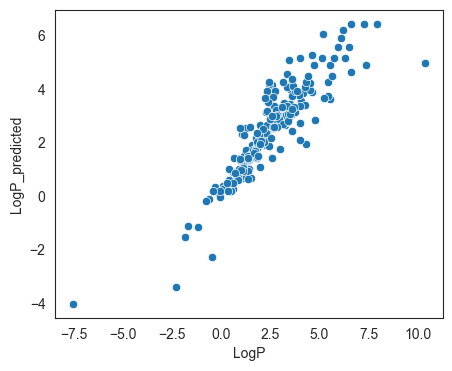

In [63]:
random_state = 42
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, idx, test_size=0.2, random_state=random_state
)

# for reference: save training compounds as df
train_esol_df = all_esol_df.iloc[indices_train].copy()
test_esol_df = all_esol_df.iloc[indices_test].copy()
train_esol_df['Source'] = ['esol_train'] * len(train_esol_df)
test_esol_df['Source'] = ['esol_test'] * len(test_esol_df)

# train a regressor of your choice:
model = RandomForestRegressor(random_state=random_state)
model.fit(X_train, y_train)
# predict logP for test set
y_pred = model.predict(X_test)
test_esol_df['LogP_predicted'] = y_pred

# Check performance
print('Test R²:', r2_score(y_test, y_pred))
print('Test RMSE:', root_mean_squared_error(y_test, y_pred))
plt.figure(figsize=(5, 4))
sns.set_style('white')
sns.scatterplot(test_esol_df, x='LogP', y='LogP_predicted')
plt.show()

### 4. Define a set of test molecules

In [95]:
external_test_molecules = {
    'Estradiol (hormone)': 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3C=CC(=C4)O',
    
    'PFOA (PFAS)': 'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O',
    
    'Bisphenol A (endocrine disruptor)': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
    
    'Copper sulfate (metal salt)': '[O-]S(=O)(=O)[O-].[Cu+2]',
    
    'Fullerene (nanomaterial)' : 'C12=C3C4=C5C6=C1C7=C8C9=C1C%10=C%11C(=C29)C3=C2C3=C4C4=C5C5=C9C6=C7C6=C7C8=C1C1=C8C%10=C%10C%11=C2C2=C3C3=C4C4=C5C5=C%11C%12=C(C6=C95)C7=C1C1=C%12C5=C%11C4=C3C3=C5C(=C81)C%10=C23',
    
    'Erythromycin (antibiotic)': 'CC[C@@H]1[C@@]([C@@H]([C@H](C(=O)[C@@H](C[C@@]([C@@H]([C@H]([C@@H]([C@H](C(=O)O1)C)O[C@H]2C[C@@]([C@H]([C@@H](O2)C)O)(C)OC)C)O[C@H]3[C@@H]([C@H](C[C@H](O3)C)N(C)C)O)(C)O)C)C)O)(C)O',
    
    'Chlorophyll B (pigment)': 'CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@H](C(=N5)C=C6C(=C(C(=C2)[N-]6)C=C)C)C)CCC(=O)OC/C=C(\C)/CCC[C@H](C)CCC[C@H](C)CCCC(C)C)[C@H](C4=O)C(=O)OC)C)C=O.[Mg+2]',
    
    'DNA (polymer)' : 'CC1=CN(C(=O)NC1=O)C2CC(C(O2)COP(=S)(O)OC3CC(OC3COP(=S)(O)OC4CC(OC4COP(=S)(O)OC5CC(OC5COP(=S)(O)OC6CC(OC6COP(=S)(O)OC7CC(OC7COP(=S)(O)OC8CC(OC8COP(=S)(O)OC9CC(OC9COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1CO)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=NC2=C1N=C(NC2=O)N)N1C=CC(=NC1=O)N)N1C=NC2=C(N=CN=C21)N)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=NC2=C(N=CN=C21)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)O',
}
test_ext_df = pd.DataFrame()
test_ext_df['Name'] = external_test_molecules.keys()
test_ext_df['SMILES'] = external_test_molecules.values()
template_df = test_ext_df.copy() # as a template for data collection


### 5. Predict logP for external test molecules

In [96]:
X_test_mols, _ = maccs_fp_from_smiles(test_ext_df.SMILES)
y_test_pred = model.predict(X_test_mols) # predict logP

# Add results to data frame
test_ext_df[f'LogP_pred'] = y_test_pred
test_ext_df['run_ID'] = [f'{random_state}_RF'] * len(y_test_pred)
test_ext_df['method'] = ['RF'] * len(y_test_pred)

print('\n*** LogP predictions ***\n')
print(test_ext_df.drop(columns=['SMILES']))


*** LogP predictions ***

                                Name  LogP_pred  run_ID method
0                Estradiol (hormone)   4.060705  482_RF     RF
1                        PFOA (PFAS)   1.339504  482_RF     RF
2  Bisphenol A (endocrine disruptor)   3.636438  482_RF     RF
3        Copper sulfate (metal salt)   0.345612  482_RF     RF
4           Fullerene (nanomaterial)   3.963474  482_RF     RF
5          Erythromycin (antibiotic)  -0.533373  482_RF     RF
6            Chlorophyll B (pigment)   4.211739  482_RF     RF
7                      DNA (polymer)   1.394668  482_RF     RF


### 6. Collect predictions from different models

Train different models on different splits and/or using different random seeds and collect the results


In [114]:
# Very important first step: choose a random seed OTHER than 42 (or 0 or 1)
random_state = 492

models = {'RF': RandomForestRegressor(random_state=random_state),
          'GB': GradientBoostingRegressor(random_state=random_state),
          'AB': AdaBoostRegressor(random_state=random_state),
          'kNN': KNeighborsRegressor(),
          'Ridge': Ridge(random_state=random_state),
          'SGD': SGDRegressor(random_state=random_state),
          }

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, idx, test_size=0.2, random_state=random_state
)

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test_mols) # predict logP
    # Add results to data frame
    this_df = template_df.copy()
    # Add results to data frame
    this_df[f'LogP_pred'] = y_test_pred
    this_df['run_ID'] = [f'{random_state}_{model_name}'] * len(y_test_pred)
    this_df['method'] = [model_name] * len(y_test_pred)
    test_ext_df = pd.concat([test_ext_df, this_df])

Plot the distribution of model predictions for each substance

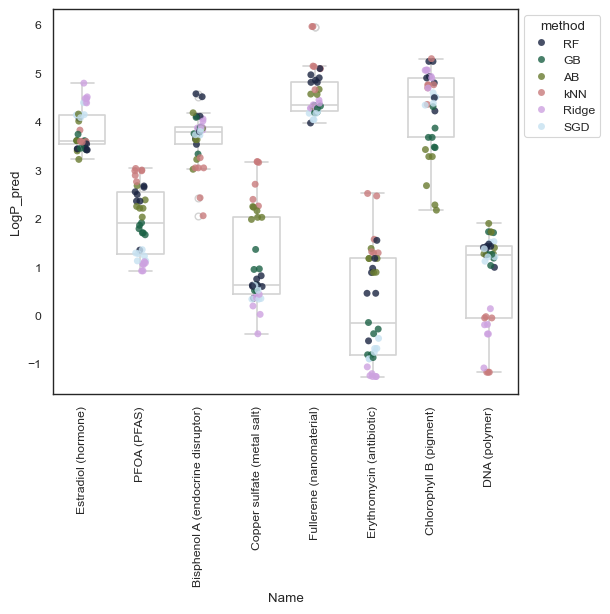

In [124]:
plt.figure(figsize=(6, 5))
sns.set_context('paper')

ax = sns.boxplot(data=test_ext_df, x='Name', y='LogP_pred', fill=False, color='lightgrey',
                    )
plt.xticks(rotation=90)
sns.stripplot(data=test_ext_df, x='Name', y='LogP_pred', hue='method', ax=ax, palette='cubehelix', alpha=0.8)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1)) # move legend outside of plot

In [122]:
stats = test_ext_df.groupby("Name")["LogP_pred"].agg(["mean", "std"])
stats_sorted = stats.sort_values(by="std")
print(stats_sorted)

                                       mean       std
Name                                                 
Estradiol (hormone)                3.830408  0.412119
Fullerene (nanomaterial)           4.541820  0.480163
Bisphenol A (endocrine disruptor)  3.656964  0.507741
PFOA (PFAS)                        1.938589  0.703444
Chlorophyll B (pigment)            4.277513  0.815296
DNA (polymer)                      0.776072  0.950458
Copper sulfate (metal salt)        1.142513  0.993642
Erythromycin (antibiotic)          0.184527  1.142081


### 8. Discussion

- Are the results in line with the AD metrics from last week?
- Which predictions would you trust?
- How can we evaluate whether the prediction uncertainties are trustworthy?

1) it is quite similar to last week
2) all thogether is probbaly better then just one.